# Classification: Ensemble Methods & Class Imbalance

This practical develops the Data Mining learning outcome on **ensemble classification and class-imbalance handling**. Previously studied classifiers are used as baselines, not taught again.

**Prerequisites:** [classification and regression in Modul-ML-RKA](https://github.com/kcv-if/Modul-ML-RKA/tree/main/Supervised%20Learning), train/test splitting, and basic classification metrics.

**Learning goals:** explain bootstrap, bagging, Random Forest, and boosting; recognize misleading accuracy on imbalanced data; compare resampling and class weighting without data leakage; interpret minority-class performance and error costs.

**Environment for Sections 1–3:** Python, NumPy, pandas, Matplotlib, scikit-learn **1.2 or newer** (`BaggingClassifier(estimator=...)`), and a compatible imbalanced-learn release. Core examples use bundled or synthetic datasets; no external dataset download is needed.

Run Sections **1–3 in order from a fresh kernel**. Appendices are optional reference material with separate dependencies and datasets.

## Learning path

1. **Ensemble methods:** motivation → bootstrap → bagging → Random Forest → boosting/AdaBoost.
2. **Class imbalance:** problem → suitable metrics → handling strategies.
3. **Integrated practical:** stratified split → baseline and treatment models → evaluation → error costs → interpretation.
4. **Optional appendices:** feature selection, alternative classifiers, specialized supervision, stream data, and extended evaluation.

References to the original E-Book 1 sections are retained alongside the new teaching order.

## 1. Ensemble methods

### 1.1. Why combine models?

*Book reference: Section 6.7.1.*

An ensemble combines predictions from several models. Its benefit depends on both member quality and diversity: models that make identical mistakes add little value. An ensemble is not guaranteed to outperform every individual model.

This practical focuses on two families:

- **Bagging:** train members independently on bootstrap samples, then aggregate predictions. It often reduces variance for unstable learners such as decision trees.
- **Boosting:** train members sequentially so later learners address weaknesses of the current ensemble. AdaBoost changes training-example weights; other boosting algorithms need not use the same mechanism.

Before fitting either family, the following small example demonstrates **hard voting** only. Three classifiers already produced predictions for the same four observations; take the majority label for each observation. Random Forest training is introduced after bagging.

In [17]:
from collections import Counter

member_predictions = [
    [0, 1, 1, 0],
    [0, 1, 0, 0],
    [1, 1, 1, 0],
]
ensemble_predictions = [
    Counter(votes).most_common(1)[0][0] for votes in zip(*member_predictions)
]
print("Member predictions:", member_predictions)
print("Majority-vote predictions:", ensemble_predictions)


Member predictions: [[0, 1, 1, 0], [0, 1, 0, 0], [1, 1, 1, 0]]
Majority-vote predictions: [0, 1, 1, 0]


The ensemble predictions are `[0, 1, 1, 0]`. Three voters and two possible labels prevent ties in this example. Voting combines outputs; it does not specify how the member models were trained.

### 1.2. Bootstrap: sampling with replacement

*Book reference: Section 6.6.4.*

A bootstrap sample draws **N observations with replacement** from an observed dataset of size N. Some observations appear repeatedly and others are absent. Repeating this process produces different training samples without collecting new data.

Bootstrap has two uses relevant here:

1. Estimate uncertainty in a statistic, illustrated below by the mean Iris sepal length.
2. Generate diverse training samples for bagging, introduced next.

A bootstrap percentile interval is an approximate uncertainty estimate under the sampling assumptions. Bootstrap does not automatically make an estimator robust to outliers.

In [18]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.utils import resample

bootstrap_values = load_iris().data[:, 0]
bootstrap_rng = np.random.RandomState(42)
bootstrap_means = np.empty(1000)
for index in range(len(bootstrap_means)):
    bootstrap_sample = resample(
        bootstrap_values,
        replace=True,
        n_samples=len(bootstrap_values),
        random_state=bootstrap_rng,
    )
    bootstrap_means[index] = bootstrap_sample.mean()

bootstrap_interval = np.percentile(bootstrap_means, [2.5, 97.5])
print(f"Observed mean: {bootstrap_values.mean():.2f}")
print(f"Bootstrap mean: {bootstrap_means.mean():.2f}")
print(f"Approximate 95% interval: {bootstrap_interval}")


Observed mean: 5.84
Bootstrap mean: 5.84
Approximate 95% interval: [5.71063333 5.97268333]


Each resample retains the original sample size but can repeat observations. Bagging uses this same sampling principle to train models instead of estimating a mean.

### 1.3. Bagging: independent models on bootstrap samples

*Book reference: Section 6.7.2.*

**Bootstrap aggregating (bagging)** fits a base learner independently on each bootstrap sample. Predictions are aggregated across learners. This can reduce variance, especially when a small change in training data substantially changes the base learner.

The example uses **`BaggingClassifier` with decision trees**, not Random Forest. `max_features=1.0` makes all input features available to each bagged tree; there is no Random Forest-style feature subsampling at each split.

In [19]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

bagging_data = load_breast_cancer()
bagging_X_train, bagging_X_test, bagging_y_train, bagging_y_test = train_test_split(
    bagging_data.data,
    bagging_data.target,
    test_size=0.2,
    stratify=bagging_data.target,
    random_state=42,
)
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    bootstrap=True,
    max_features=1.0,
    random_state=42,
)
bagging_model.fit(bagging_X_train, bagging_y_train)
bagging_predictions = bagging_model.predict(bagging_X_test)
print(f"Bagging accuracy: {accuracy_score(bagging_y_test, bagging_predictions):.2f}")
print(classification_report(bagging_y_test, bagging_predictions, zero_division=0))


Bagging accuracy: 0.94
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



The trees receive different bootstrap samples, then their class probabilities are averaged by `BaggingClassifier`. These are ordinary bagged decision trees. Next, Random Forest adds randomness within each tree's split search.

### 1.4. Random Forest: bagging plus random split features

*Book reference: Section 6.7.4.*

Random Forest combines bootstrap-trained decision trees with **random feature subsets considered at each split**. This can reduce correlation between trees beyond ordinary bagging.

- **Bootstrap samples:** different training observations for different trees.
- **Random split features:** `max_features="sqrt"` considers a subset of features at each split.
- **Aggregation:** scikit-learn averages class probabilities across trees before assigning the predicted class.

Use the same dataset and deterministic split as the bagging example so the model difference is visible. Random Forest does not automatically solve class imbalance; its minority-class behavior must still be evaluated.

In [20]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

forest_data = load_breast_cancer()
forest_X_train, forest_X_test, forest_y_train, forest_y_test = train_test_split(
    forest_data.data,
    forest_data.target,
    test_size=0.2,
    stratify=forest_data.target,
    random_state=42,
)
forest_model = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
)
forest_model.fit(forest_X_train, forest_y_train)
forest_predictions = forest_model.predict(forest_X_test)
print(
    f"Random Forest accuracy: {accuracy_score(forest_y_test, forest_predictions):.2f}"
)
print(classification_report(forest_y_test, forest_predictions, zero_division=0))


Random Forest accuracy: 0.96
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Bagging and Random Forest now represent distinct implementations on identical train/test observations. A higher score in one split is not proof that one method always wins.

### 1.5. Boosting with AdaBoost

*Book reference: Section 6.7.3.*

Unlike independent bagging members, **AdaBoost** trains weak learners sequentially. Initially, examples have equal weights. Misclassified examples receive greater weight for the next learner, and the final model combines learner contributions according to their performance.

The default weak learner in scikit-learn's `AdaBoostClassifier` is a shallow decision tree. Boosting can capture patterns missed by a single weak learner, but noisy labels and outliers can receive excessive attention. This example illustrates AdaBoost on Iris; it is not a controlled performance comparison with the Breast Cancer examples above.

In [21]:
from sklearn.datasets import load_iris
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

boosting_data = load_iris()
boosting_X_train, boosting_X_test, boosting_y_train, boosting_y_test = train_test_split(
    boosting_data.data,
    boosting_data.target,
    test_size=0.2,
    stratify=boosting_data.target,
    random_state=42,
)
boosting_model = AdaBoostClassifier(n_estimators=50, random_state=42)
boosting_model.fit(boosting_X_train, boosting_y_train)
boosting_predictions = boosting_model.predict(boosting_X_test)
print(f"AdaBoost accuracy: {accuracy_score(boosting_y_test, boosting_predictions):.2f}")
print(classification_report(boosting_y_test, boosting_predictions, zero_division=0))


AdaBoost accuracy: 0.93
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Bagging and Random Forest diversify independently trained trees; AdaBoost changes the training focus sequentially. With these models introduced, the next section examines class imbalance rather than assuming an ensemble will fix it.

## 2. Class imbalance

### 2.1. Why accuracy can be misleading

*Book reference: Section 6.7.5.*

Class imbalance means class frequencies differ substantially. A learner can favor the majority class and still obtain high overall accuracy while failing on the minority class.

In the binary examples below, **label 0 is the majority class and label 1 is the minority/positive class**. Predicting 0 for every observation in a 99:1 dataset yields 99% accuracy, but detects none of the minority observations. No class labels need to be changed to create this distribution.

In [22]:
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score

imbalance_demo_y = np.array([0] * 990 + [1] * 10)
majority_only_predictions = np.zeros_like(imbalance_demo_y)
print("Accuracy:", accuracy_score(imbalance_demo_y, majority_only_predictions))
print(
    "Balanced accuracy:",
    balanced_accuracy_score(imbalance_demo_y, majority_only_predictions),
)
print(
    "Minority recall:",
    recall_score(imbalance_demo_y, majority_only_predictions, pos_label=1),
)


Accuracy: 0.99
Balanced accuracy: 0.5
Minority recall: 0.0


### 2.2. Metrics for the minority class

Basic metric definitions belong to the ML prerequisites. For imbalance, their **choice and interpretation** matter:

- **Minority recall:** how many true minority observations are detected? Essential when missed positive cases are costly.
- **Minority precision/F1:** examine false alarms as well as missed cases.
- **Macro-F1:** gives each class equal weight instead of letting the majority dominate an average.
- **Balanced accuracy:** averages recall across classes; the majority-only example above scores 0.5, not 0.99.
- **Precision–recall curve and average precision (AP):** evaluate minority-class probability rankings. AP summarizes precision over recall increments; it is not the same calculation as trapezoidal PR area.
- **Confusion matrix and error cost:** interpret errors in the application context.

ROC-AUC can provide a complementary ranking view, but should not replace minority precision–recall analysis on heavily imbalanced data. Always state the positive label and class prevalence. Metric priorities should be fixed from the application objective, not chosen after inspecting the test results.

### 2.3. Handling strategies and leakage prevention

1. **Random undersampling:** remove majority training observations. This is inexpensive but can discard useful information.
2. **Random oversampling:** duplicate minority training observations. It increases minority representation but can encourage overfitting.
3. **SMOTE:** generate synthetic training observations between minority neighbors. Adequate minority sample size and meaningful feature distances are required; synthetic points can amplify noise or cross class boundaries. This example uses numerical features; do not apply ordinary SMOTE blindly to categorical data.
4. **Class weighting:** penalize minority errors more strongly during model fitting, for example `class_weight="balanced"` in Random Forest.
5. **Cost-sensitive decisions:** distinguish false-positive and false-negative consequences. If tuning a probability threshold, use training/validation data, never the final test set.

**Split first.** Fit preprocessing and resampling only on training data. An `imblearn.pipeline.Pipeline` keeps scaling and sampling inside model fitting, including inside cross-validation folds if tuning is added later. Leave test observations and their original class distribution unchanged.

An ensemble is not an imbalance treatment by itself. Anomaly detection can be considered when the minority represents anomalies, but that is a separate modeling decision rather than a universal replacement for classification.

## 3. Integrated practical: compare models on the same imbalanced data

### 3.1. Generate data and make a stratified split

Generate a binary dataset with approximately 90% majority observations and 10% minority observations. **Do not merge or relabel classes.** Stratification keeps the class proportions similar in the training and test sets.

The same fixed test observations are used for every comparison. Examples below use separate `imb_` names to avoid depending on variables from the standalone ensemble demonstrations.

In [23]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

imb_X, imb_y = make_classification(
    n_samples=1200,
    n_features=12,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    weights=[0.9, 0.1],
    flip_y=0.01,
    random_state=42,
)
imb_feature_names = [f"feature_{index}" for index in range(imb_X.shape[1])]
imb_X_train, imb_X_test, imb_y_train, imb_y_test = train_test_split(
    imb_X,
    imb_y,
    test_size=0.25,
    stratify=imb_y,
    random_state=42,
)
imb_class_counts = pd.DataFrame(
    {
        "all": np.bincount(imb_y, minlength=2),
        "train": np.bincount(imb_y_train, minlength=2),
        "test": np.bincount(imb_y_test, minlength=2),
    },
    index=["majority (0)", "minority (1)"],
)
print(imb_class_counts)
print(f"Test minority prevalence: {(imb_y_test == 1).mean():.3f}")


               all  train  test
majority (0)  1077    808   269
minority (1)   123     92    31
Test minority prevalence: 0.103


### 3.2. Fit baselines, resampling pipelines, and class weighting

Compare a majority-only dummy, a previously studied Decision Tree baseline, ordinary Random Forest, and Random Forest with four imbalance treatments. Keep Random Forest settings fixed so treatment effects are easier to inspect.

Each resampling pipeline fits its scaler on training data, samples that training data, then fits the forest. At prediction time the sampler is not applied to the test set. The scaler makes distances more comparable for SMOTE; scaling is not intrinsically required by Random Forest.

In [24]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


def make_imbalance_forest(class_weight=None):
    return RandomForestClassifier(
        n_estimators=100,
        class_weight=class_weight,
        random_state=42,
    )


def make_sampling_pipeline(sampler):
    return Pipeline(
        [
            ("scale", StandardScaler()),
            ("sample", sampler),
            ("model", make_imbalance_forest()),
        ]
    )


imb_models = {
    "Majority-only dummy": DummyClassifier(strategy="most_frequent"),
    "Decision Tree baseline": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": make_imbalance_forest(),
    "Random Forest + class weights": make_imbalance_forest(class_weight="balanced"),
    "Random Forest + undersampling": make_sampling_pipeline(
        RandomUnderSampler(random_state=42)
    ),
    "Random Forest + oversampling": make_sampling_pipeline(
        RandomOverSampler(random_state=42)
    ),
    "Random Forest + SMOTE": make_sampling_pipeline(SMOTE(random_state=42)),
}
for imb_name, imb_model in imb_models.items():
    imb_model.fit(imb_X_train, imb_y_train)
    print("Fitted:", imb_name)


Fitted: Majority-only dummy
Fitted: Decision Tree baseline
Fitted: Random Forest
Fitted: Random Forest + class weights
Fitted: Random Forest + undersampling
Fitted: Random Forest + oversampling
Fitted: Random Forest + SMOTE


### 3.3. Evaluate minority performance and precision–recall curves

Report both threshold-dependent classification metrics and ranking metrics on the untouched test set. The positive class is explicitly label 1. Do not assume that sampling or class weighting must improve every metric: minority recall can increase while precision decreases.

The test table is a final demonstration comparison, not a search for hyperparameters or thresholds. A deployed model should be selected using separate validation or cross-validation on training data, according to the metric priorities established earlier.

                               accuracy  balanced_accuracy  macro_f1  minority_precision  minority_recall  minority_f1  average_precision
model                                                                                                                                    
Majority-only dummy               0.897              0.500     0.473               0.000            0.000        0.000              0.103
Decision Tree baseline            0.937              0.779     0.810               0.750            0.581        0.655              0.553
Random Forest                     0.947              0.742     0.812               1.000            0.484        0.652              0.892
Random Forest + class weights     0.930              0.676     0.737               0.917            0.355        0.512              0.865
Random Forest + undersampling     0.880              0.876     0.765               0.458            0.871        0.600              0.604
Random Forest + oversampling      

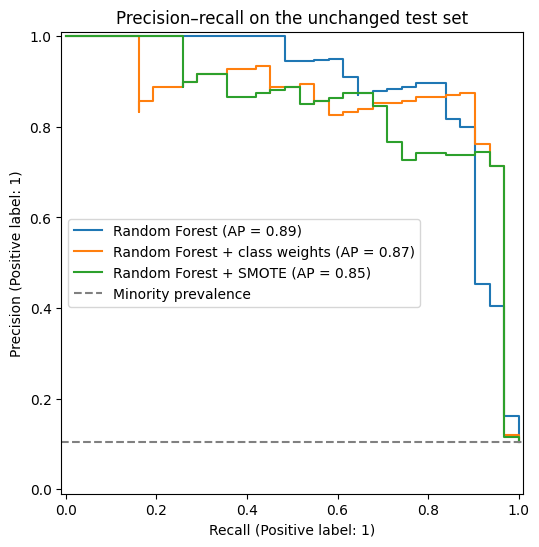

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    PrecisionRecallDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

imb_result_rows = []
for imb_name, imb_model in imb_models.items():
    imb_predictions = imb_model.predict(imb_X_test)
    imb_positive_index = np.flatnonzero(imb_model.classes_ == 1)[0]
    imb_scores = imb_model.predict_proba(imb_X_test)[:, imb_positive_index]
    imb_result_rows.append(
        {
            "model": imb_name,
            "accuracy": accuracy_score(imb_y_test, imb_predictions),
            "balanced_accuracy": balanced_accuracy_score(imb_y_test, imb_predictions),
            "macro_f1": f1_score(
                imb_y_test, imb_predictions, average="macro", zero_division=0
            ),
            "minority_precision": precision_score(
                imb_y_test, imb_predictions, pos_label=1, zero_division=0
            ),
            "minority_recall": recall_score(
                imb_y_test, imb_predictions, pos_label=1, zero_division=0
            ),
            "minority_f1": f1_score(
                imb_y_test, imb_predictions, pos_label=1, zero_division=0
            ),
            "average_precision": average_precision_score(
                imb_y_test, imb_scores, pos_label=1
            ),
        }
    )
imb_results = pd.DataFrame(imb_result_rows).set_index("model")
print(imb_results.round(3).to_string())

imb_curve_names = [
    "Random Forest",
    "Random Forest + class weights",
    "Random Forest + SMOTE",
]
imb_pr_figure, imb_pr_axis = plt.subplots(figsize=(8, 6))
for imb_name in imb_curve_names:
    PrecisionRecallDisplay.from_estimator(
        imb_models[imb_name],
        imb_X_test,
        imb_y_test,
        pos_label=1,
        name=imb_name,
        ax=imb_pr_axis,
    )
imb_test_prevalence = (imb_y_test == 1).mean()
imb_pr_axis.axhline(
    imb_test_prevalence, linestyle="--", color="gray", label="Minority prevalence"
)
imb_pr_axis.set_title("Precision–recall on the unchanged test set")
imb_pr_axis.legend()
plt.show()


### 3.4. Compare error costs and complementary ROC curves

*Book reference: Section 6.6.6.*

Assume a missed minority observation costs **5 units**, while a false alarm costs **1 unit**. With positive label 1, `confusion_matrix(..., labels=[0, 1])` contains `[[TN, FP], [FN, TP]]`. Calculate `total_cost = FP × 1 + FN × 5`; do not transpose a cost matrix and accidentally swap the penalties.

Costs below use each fitted model's default class decision. Altering a threshold is a separate validation-based decision. ROC curves complement the preceding precision–recall analysis; they are not a substitute for it.

                               false_positives  false_negatives  total_cost
model                                                                      
Majority-only dummy                          0               31         155
Decision Tree baseline                       6               13          71
Random Forest                                0               16          80
Random Forest + class weights                1               20         101
Random Forest + undersampling               32                4          52
Random Forest + oversampling                 1               14          71
Random Forest + SMOTE                        7                8          47


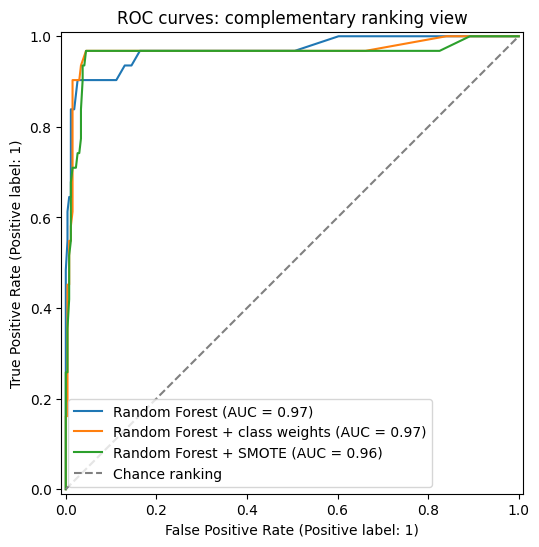

In [26]:
from sklearn.metrics import RocCurveDisplay, confusion_matrix

imb_false_positive_cost = 1
imb_false_negative_cost = 5
imb_cost_rows = []
for imb_name, imb_model in imb_models.items():
    imb_predictions = imb_model.predict(imb_X_test)
    imb_tn, imb_fp, imb_fn, imb_tp = confusion_matrix(
        imb_y_test,
        imb_predictions,
        labels=[0, 1],
    ).ravel()
    imb_cost_rows.append(
        {
            "model": imb_name,
            "false_positives": imb_fp,
            "false_negatives": imb_fn,
            "total_cost": imb_fp * imb_false_positive_cost
            + imb_fn * imb_false_negative_cost,
        }
    )
imb_costs = pd.DataFrame(imb_cost_rows).set_index("model")
print(imb_costs.to_string())

imb_roc_figure, imb_roc_axis = plt.subplots(figsize=(8, 6))
for imb_name in imb_curve_names:
    RocCurveDisplay.from_estimator(
        imb_models[imb_name],
        imb_X_test,
        imb_y_test,
        pos_label=1,
        name=imb_name,
        ax=imb_roc_axis,
    )
imb_roc_axis.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance ranking")
imb_roc_axis.set_title("ROC curves: complementary ranking view")
imb_roc_axis.legend()
plt.show()


### 3.5. Interpret the ensemble without claiming causality

Inspect the ordinary Random Forest's feature-importance scores after fitting and evaluation. These impurity-based scores describe how the fitted trees used features; they do not establish causal relationships. Correlated features can share importance, and high-cardinality features can receive inflated scores.

SHAP is retained as optional extended interpretation in Appendix E.2, not required for this practical.

feature_4     0.185
feature_11    0.134
feature_6     0.124
feature_0     0.085
feature_2     0.078
feature_8     0.077
feature_5     0.070
feature_3     0.069
feature_9     0.050
feature_10    0.046
feature_1     0.042
feature_7     0.039


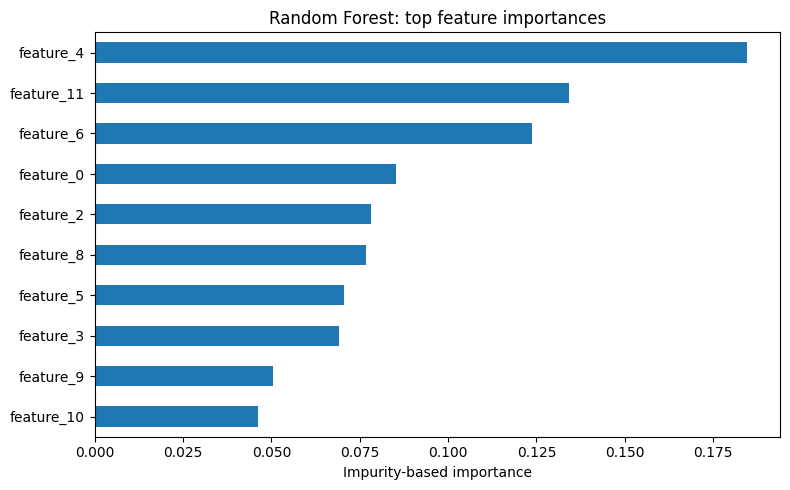

In [27]:
imb_importance = pd.Series(
    imb_models["Random Forest"].feature_importances_,
    index=imb_feature_names,
    name="impurity_importance",
).sort_values(ascending=False)
print(imb_importance.round(3).to_string())
imb_importance.head(10).sort_values().plot.barh(figsize=(8, 5))
plt.xlabel("Impurity-based importance")
plt.title("Random Forest: top feature importances")
plt.tight_layout()
plt.show()


### 3.6. Discussion and practical checklist

- Explain why the majority-only dummy's accuracy is insufficient.
- Compare minority recall, precision, macro-F1, average precision, and total error cost before and after treatment. Identify trade-offs rather than declaring one method universally best.
- Explain how bagging differs from Random Forest and why AdaBoost trains members sequentially.
- Verify that every fitted scaler and sampler saw training observations only, and that all methods were evaluated on identical test observations.
- Keep feature selection, resampling, and threshold/hyperparameter tuning inside training/validation procedures. Do not tune on the final test set.
- State the positive label, class proportions, application cost assumptions, and limitations of this synthetic example.

The required practical ends here. Advanced statistical comparison is optional in Appendix E.1.

## Optional appendices

The following original reference topics are grouped by purpose. They are **not prerequisites** for Sections 1–3 and are tagged `optional-reference`.

For the required practical, run **Sections 1–3 only**. Do not use Run All on the entire notebook unless the selected appendices' datasets, extra packages, and version-specific APIs are ready. These retained examples include legacy assumptions; rearranging them does not establish their runtime correctness.

## Appendix A. Feature selection and optimization

These extensions belong after preprocessing foundations. Optimization-based feature search is optional and more advanced than filter or wrapper selection.

### A.1. Attribute selection measures

*Book reference: Section 6.2.2.*

In the context of data mining and machine learning, attribute selection measures, also known as feature selection, refer to the process of choosing a subset of relevant features from a larger set of features. The goal is to improve the model's performance, reduce overfitting, and enhance interpretability. There are various attribute selection measures, each with its own criteria for evaluating the importance of features. Some common 
#### measures include:

Information gain and Gini impurity for decision-tree splits are covered in the ML module and are not repeated here. Additional measures include:

1. Gain Ratio: Normalizes information gain by split information, reducing the preference for attributes with many distinct values. This is a split-selection criterion rather than a standalone preprocessing selector.

2. Chi-square: Tests the independence between a feature and the class, supporting feature selection before model training.

#### Practical Example in Python:

Let's use the famous Iris dataset again and apply Information Gain as the attribute selection measure to choose the most relevant features for classification.

In [28]:
# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use Information Gain for feature selection
selector = SelectKBest(mutual_info_classif, k=2)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Create a decision tree classifier
clf = DecisionTreeClassifier()

# Fit the classifier to the selected training data
clf.fit(X_train_selected, y_train)

# Make predictions on the selected test data
predictions = clf.predict(X_test_selected)

# Display the accuracy of the model
accuracy = clf.score(X_test_selected, y_test)
print(f"Accuracy: {accuracy:.2f}")

# Display the decision tree rules for the selected features
selected_feature_names = [iris.feature_names[i] for i in selector.get_support(indices=True)]
tree_rules = export_text(clf, feature_names=selected_feature_names)
print("Decision Tree Rules for Selected Features:\n", tree_rules)


Accuracy: 1.00
Decision Tree Rules for Selected Features:
 |--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- class: 2
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: 2



    In this example, we use scikit-learn's SelectKBest with mutual information as the scoring function to select the top k features with the highest information gain. We then train a decision tree classifier on the selected features and evaluate its accuracy. This example demonstrates the practical application of attribute selection measures to enhance the performance of a machine learning model.

### A.2. Filter Methods

*Book reference: Section 7.1.1.*

Feature selection is a crucial step in the data preprocessing phase, involving the identification and selection of the most relevant features for a particular task. Filter methods are a category of feature selection techniques that evaluate the relevance of features based on certain statistical measures or scoring criteria. These methods assess the characteristics of individual features independently of the machine learning model.

#### Key Points:

1. Independence:
        Filter methods assess each feature's relevance independently of other features.

2. Scoring Criteria:
        Features are ranked or scored based on statistical measures, such as correlation, mutual information, or statistical tests.

3. Preprocessing:
        Filter methods are applied as a preprocessing step before training a machine learning model.

4. Selection Threshold:
        A threshold is set to select the top-ranked features, and the rest are discarded.

5. Advantages:
        Computationally efficient and can handle high-dimensional data.
        Model-agnostic, making them suitable for various algorithms.

#### Practical Example in Python:

Let's consider a practical example using the Breast Cancer Wisconsin dataset. We'll use the chi-squared (χ²) statistical test as a filter method to select the most relevant features.

In [29]:
# Import necessary libraries
from sklearn import datasets
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the Breast Cancer Wisconsin dataset
cancer = datasets.load_breast_cancer()
X = cancer.data
y = cancer.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SelectKBest with chi-squared test for feature selection
k_best_selector = SelectKBest(score_func=chi2, k=10)
X_train_selected = k_best_selector.fit_transform(X_train, y_train)
X_test_selected = k_best_selector.transform(X_test)

# Create a Random Forest classifier with 100 trees
random_forest_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier on the selected features
random_forest_classifier.fit(X_train_selected, y_train)

# Make predictions on the test data
predictions = random_forest_classifier.predict(X_test_selected)

# Display the accuracy and classification report
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.95
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.93        43
           1       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



    In this example, we use the chi-squared test through the SelectKBest method to select the top 10 features from the Breast Cancer Wisconsin dataset. The selected features are then used to train a Random Forest classifier, and the model's performance is evaluated on the test set.

### A.3. Wrapper Methods

*Book reference: Section 7.1.2.*

Wrapper methods are a category of feature selection techniques that evaluate subsets of features by training and testing a machine learning model on different combinations. Unlike filter methods, wrapper methods consider the interaction between features and assess subsets based on the model's performance. These methods typically use a search algorithm to explore the feature space and select the optimal subset.

#### Key Points:

- Model-Dependent:
    Wrapper methods are model-dependent, as they involve training and testing a specific machine learning model on different feature subsets.

- Search Strategy:
    The search strategy can be exhaustive (evaluating all possible subsets) or heuristic (using algorithms like forward selection or backward elimination).

- Performance Evaluation:
    Model performance serves as the criterion for selecting feature subsets. Common metrics include accuracy, F1-score, or other relevant performance measures.

- Computational Intensity:
    Wrapper methods can be computationally intensive, especially when evaluating a large number of feature subsets.

#### Practical Example in Python:

Let's consider a practical example using the Breast Cancer Wisconsin dataset. We'll use a simple wrapper method, Recursive Feature Elimination (RFE), with a Support Vector Machine (SVM) classifier to select the optimal subset of features.

In [30]:
# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, classification_report

# Load the Breast Cancer Wisconsin dataset
cancer = datasets.load_breast_cancer()
X = cancer.data
y = cancer.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel="linear", random_state=42)

# Apply Recursive Feature Elimination (RFE) for feature selection
rfe_selector = RFE(estimator=svm_classifier, n_features_to_select=10)
X_train_selected = rfe_selector.fit_transform(X_train, y_train)
X_test_selected = rfe_selector.transform(X_test)

# Train the classifier on the selected features
svm_classifier.fit(X_train_selected, y_train)

# Make predictions on the test data
predictions = svm_classifier.predict(X_test_selected)

# Display the accuracy and classification report
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, predictions))


Accuracy: 0.97
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



    In this example, we use Recursive Feature Elimination (RFE) with a Support Vector Machine (SVM) classifier to select the top 10 features from the Breast Cancer Wisconsin dataset. The selected features are then used to train the SVM classifier, and the model's performance is evaluated on the test set.

### A.4. Genetic algorithms

*Book reference: Section 7.7.4.*

Genetic algorithms search for useful feature subsets through a population of candidates, selection, crossover, and mutation. Each candidate in this example is a Boolean feature mask on the four Iris features. Tournament selection chooses parents, one-point crossover combines them, mutation toggles feature choices, and elitism preserves the best candidates.

This implementation uses NumPy and scikit-learn only. It does not depend on the legacy genetic package. The population contains 10 candidates and runs for 5 generations. Empty masks are repaired by selecting one feature.

Fitness is the mean accuracy from 3-fold stratified cross-validation on the training data only. Scores are cached for repeated masks. The final test set is held out until the feature subset has been chosen. Higher accuracy is preferred, with fewer features used to break score ties. The algorithm reports the best subset found, not a guaranteed global optimum.

In [31]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# Keep the final test set separate from feature-subset selection.
ga_data = load_iris()
ga_X_train, ga_X_test, ga_y_train, ga_y_test = train_test_split(
    ga_data.data,
    ga_data.target,
    test_size=0.2,
    stratify=ga_data.target,
    random_state=42,
)
ga_feature_count = ga_X_train.shape[1]
ga_population_size = 10
ga_generations = 5
ga_elite_count = 2
ga_crossover_probability = 0.8
ga_mutation_probability = 0.2
ga_rng = np.random.default_rng(42)
ga_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
ga_fitness_cache = {}


def ga_repair_mask(mask):
    repaired = np.asarray(mask, dtype=bool).copy()
    if repaired.shape != (ga_feature_count,):
        raise ValueError("Feature mask must have one entry per feature.")
    if not repaired.any():
        repaired[ga_rng.integers(ga_feature_count)] = True
    return repaired


def ga_fitness(mask):
    feature_mask = np.asarray(mask, dtype=bool)
    if feature_mask.shape != (ga_feature_count,) or not feature_mask.any():
        raise ValueError("Select at least one feature with a valid feature mask.")
    key = tuple(feature_mask.tolist())
    if key not in ga_fitness_cache:
        scores = cross_val_score(
            RandomForestClassifier(n_estimators=100, random_state=42),
            ga_X_train[:, feature_mask],
            ga_y_train,
            cv=ga_cv,
            scoring="accuracy",
            n_jobs=1,
        )
        ga_fitness_cache[key] = float(scores.mean())
    return ga_fitness_cache[key]


def ga_select_parent(population, scores):
    candidates = ga_rng.choice(
        len(population), size=min(3, len(population)), replace=False
    )
    winner = max(
        candidates,
        key=lambda index: (scores[index], -population[index].sum()),
    )
    return population[winner].copy()


# A True entry selects a feature. Repair candidates with no selected features.
ga_population = np.array(
    [
        ga_repair_mask(mask)
        for mask in ga_rng.integers(0, 2, size=(ga_population_size, ga_feature_count))
    ],
    dtype=bool,
)
ga_history = []
for ga_generation in range(1, ga_generations + 1):
    ga_scores = np.array([ga_fitness(mask) for mask in ga_population])
    ga_ranking = sorted(
        range(ga_population_size),
        key=lambda index: (ga_scores[index], -ga_population[index].sum()),
        reverse=True,
    )
    ga_best_index = ga_ranking[0]
    ga_history.append(float(ga_scores[ga_best_index]))
    print(
        f"Generation {ga_generation}: best training-CV accuracy "
        f"= {ga_scores[ga_best_index]:.3f}"
    )
    if ga_generation == ga_generations:
        break

    # Elitism preserves the best candidates. Prefer fewer features on score ties.
    ga_next_population = [
        ga_population[index].copy() for index in ga_ranking[:ga_elite_count]
    ]
    while len(ga_next_population) < ga_population_size:
        ga_parent_a = ga_select_parent(ga_population, ga_scores)
        ga_parent_b = ga_select_parent(ga_population, ga_scores)
        ga_child = ga_parent_a.copy()
        if ga_feature_count > 1 and ga_rng.random() < ga_crossover_probability:
            ga_cut = int(ga_rng.integers(1, ga_feature_count))
            ga_child[ga_cut:] = ga_parent_b[ga_cut:]
        ga_mutations = ga_rng.random(ga_feature_count) < ga_mutation_probability
        ga_child[ga_mutations] = ~ga_child[ga_mutations]
        ga_next_population.append(ga_repair_mask(ga_child))
    ga_population = np.array(ga_next_population, dtype=bool)

# Fit the chosen subset on all training data, then evaluate the untouched test set.
ga_best_mask = ga_population[ga_best_index].copy()
ga_best_features = np.flatnonzero(ga_best_mask)
ga_final_model = RandomForestClassifier(n_estimators=100, random_state=42)
ga_final_model.fit(ga_X_train[:, ga_best_mask], ga_y_train)
ga_test_predictions = ga_final_model.predict(ga_X_test[:, ga_best_mask])
ga_test_accuracy = accuracy_score(ga_y_test, ga_test_predictions)
print("Best feature indices:", ga_best_features.tolist())
print(
    "Selected feature names:", np.asarray(ga_data.feature_names)[ga_best_mask].tolist()
)
print(f"Best training-CV accuracy: {ga_history[-1]:.3f}")
print(f"Final held-out test accuracy: {ga_test_accuracy:.3f}")


Generation 1: best training-CV accuracy = 0.950
Generation 2: best training-CV accuracy = 0.958
Generation 3: best training-CV accuracy = 0.958
Generation 4: best training-CV accuracy = 0.967
Generation 5: best training-CV accuracy = 0.967
Best feature indices: [3]
Selected feature names: ['petal width (cm)']
Best training-CV accuracy: 0.967
Final held-out test accuracy: 0.933


The search evaluates feature masks using training-only cross-validation, with crossover probability 0.8, mutation probability 0.2 per feature, and two elite candidates retained between generations. After selection, a Random Forest is fitted on all training observations with the chosen features and evaluated once on the untouched test set. Rerun this entire cell independently; no import from genetic is required.

## Appendix B. Alternative classifiers and rule-based approaches

These topics are retained because they were not covered by the referenced ML material. They are separate classification approaches, not prerequisites for ensemble training.

### B.1. Case-based reasoning

*Book reference: Section 6.4.2.*

Case-Based Reasoning is a problem-solving approach that relies on retrieving and adapting solutions from past experiences or cases. It operates on the principle that similar problems have similar solutions. CBR consists of four main steps:

1. Retrieve: Identify similar cases from the case base (database of past experiences) based on the current problem.

2. Reuse: Apply the solution from the retrieved case to the current problem. If an exact match is not found, adapt the solution to fit the current context.

3. Revise: Evaluate the solution's success and, if necessary, revise the solution based on feedback or new information.

4. Retain: Store the new case in the case base for future use.

CBR is particularly useful in situations where traditional rule-based or model-based approaches may be challenging due to uncertainty, complexity, or changing environments.
#### Practical Example in Python:

Let's consider a practical example of case-based reasoning for a recommendation system. We'll use the MovieLens dataset and recommend movies based on user preferences.

In [32]:
# Import necessary libraries
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the MovieLens dataset (you may need to adjust the path)
movies = pd.read_csv('path_to_movielens_dataset/movies.csv')
ratings = pd.read_csv('path_to_movielens_dataset/ratings.csv')

# Merge movies and ratings data
movie_ratings = pd.merge(ratings, movies, on='movieId')

# Create a user-item matrix for collaborative filtering
user_item_matrix = movie_ratings.pivot_table(index='userId', columns='title', values='rating', fill_value=0)

# Use TF-IDF to convert movie titles into numerical features
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(movies['title'])

# Calculate cosine similarity between movie titles
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Function to get movie recommendations using CBR
def get_movie_recommendations(movie_title):
    movie_index = movies.index[movies['title'] == movie_title].tolist()[0]
    cosine_scores = list(enumerate(cosine_sim[movie_index]))
    cosine_scores = sorted(cosine_scores, key=lambda x: x[1], reverse=True)
    top_similar_movies = cosine_scores[1:6]  # Exclude the input movie itself

    recommended_movies = []
    for index, score in top_similar_movies:
        recommended_movies.append(movies['title'].iloc[index])

    return recommended_movies

# Example usage
input_movie = "The Dark Knight"
recommendations = get_movie_recommendations(input_movie)

# Display the recommendations
print(f"Movies similar to '{input_movie}':")
for movie in recommendations:
    print("-", movie)


FileNotFoundError: [Errno 2] No such file or directory: 'path_to_movielens_dataset/movies.csv'

    In this example, we use case-based reasoning to recommend movies based on the similarity of their titles. The TF-IDF vectorizer is used to convert movie titles into numerical features, and cosine similarity is calculated to measure the similarity between movies. The get_movie_recommendations function retrieves similar movies based on the input movie title.

### B.2. Distance metric learning

*Book reference: Section 7.7.2.*

Distance metric learning aims to optimize the metric used to measure the similarity or dissimilarity between data points. By learning a suitable distance metric, it becomes possible to improve the effectiveness of algorithms that rely on distances, such as clustering or nearest neighbors.
Real-world Example in Python:

Let's consider a practical example of distance metric learning using the metric_learn library in Python. We'll use the well-known Iris dataset and the Large Margin Nearest Neighbor (LMNN) algorithm.

In [33]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from metric_learn import LMNN

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Large Margin Nearest Neighbor (LMNN) for distance metric learning
lmnn = LMNN(k=3, learn_rate=1e-6)
lmnn.fit(X_train, y_train)

# Transform the data using the learned metric
X_train_transformed = lmnn.transform(X_train)
X_test_transformed = lmnn.transform(X_test)

# Train a k-Nearest Neighbors classifier on the transformed data
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train_transformed, y_train)

# Make predictions on the test set
predictions = knn_classifier.predict(X_test_transformed)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)


ModuleNotFoundError: No module named 'metric_learn'

    In this example, we use the metric_learn library to apply the Large Margin Nearest Neighbor (LMNN) algorithm for distance metric learning on the Iris dataset. The learned metric is then used to transform the data, and a k-Nearest Neighbors classifier is trained on the transformed data. The accuracy metric is used to assess the performance of the model.

### B.3. Using IF-THEN rules for classification

*Book reference: Section 7.4.1.*

#### IF-THEN Rules for Classification:

Rule-based classification involves the creation of a set of rules that determine the class or category of an instance based on its feature values. Each rule typically takes the form "IF condition THEN class." These rules are human-readable and provide transparency into the decision-making process. Rule-based systems are often employed in scenarios where interpretability and explainability are crucial.

#### Key Concepts:

- IF-THEN Structure:
    Each rule specifies a condition based on feature values, and the corresponding action (classification) to take if the condition is met.

- Rule Order:
    Rules are usually evaluated sequentially, and the first rule that matches the conditions is applied.

- Interpretability:
    Rule-based systems are transparent, making them easy to interpret and explain.

- Rule Learning:
    Rule-based models can be manually crafted or learned from data through techniques like decision tree induction.

#### Practical Example in Python:

Let's consider a practical example using the famous Iris dataset to demonstrate the application of rule-based classification. We'll use the "fuzzy" library in Python to define IF-THEN rules based on fuzzy logic.

In [ ]:
from fuzzy import FuzzySystem, Rule, Antecedent, Consequent
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define fuzzy antecedents
sepal_length = Antecedent("Sepal Length", X_train[:, 0])
sepal_width = Antecedent("Sepal Width", X_train[:, 1])
petal_length = Antecedent("Petal Length", X_train[:, 2])
petal_width = Antecedent("Petal Width", X_train[:, 3])

# Define fuzzy consequents
setosa = Consequent("Setosa", y_train == 0)
versicolor = Consequent("Versicolor", y_train == 1)
virginica = Consequent("Virginica", y_train == 2)

# Define IF-THEN rules based on fuzzy logic
rules = [
    Rule(sepal_length["low"] | sepal_width["medium"], setosa),
    Rule(petal_length["medium"] & petal_width["high"], versicolor),
    Rule(sepal_length["high"] & petal_length["medium"], virginica),
]

# Create the fuzzy system
fuzzy_system = FuzzySystem(rules)

# Make predictions on the test data
predictions = fuzzy_system.predict(X_test)

# Display the accuracy and classification report
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, predictions))


    In this example, we use the "fuzzy" library to define IF-THEN rules based on fuzzy logic for classifying Iris flowers. Fuzzy logic allows us to express rules in a more flexible manner than traditional crisp logic. 

### B.4. Rule extraction from a decision tree

*Book reference: Section 7.4.2.*

Rule extraction involves transforming the decision rules embedded in a decision tree model into a set of explicit IF-THEN rules. Decision trees inherently provide a set of rules used for classification, but extracting these rules can enhance interpretability and facilitate the manual creation or modification of rules.

#### Key Concepts:

- Decision Tree Rules:
    Decision trees make decisions based on a set of rules inferred from the features of the data.

- Leaf Nodes:
    Each leaf node in a decision tree corresponds to a specific class or outcome.

- Rule Extraction Process:
    The process involves traversing the decision tree and extracting the conditions present on the path from the root to each leaf.

#### Practical Example in Python:

Let's consider a practical example using the Iris dataset to demonstrate the extraction of rules from a decision tree. We'll use the "sklearn.tree" module in Python.

In [ ]:
# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, classification_report

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Decision Tree classifier
decision_tree_classifier = DecisionTreeClassifier(random_state=42)

# Train the classifier on the training data
decision_tree_classifier.fit(X_train, y_train)

# Extract rules from the decision tree
tree_rules = export_text(decision_tree_classifier, feature_names=iris.feature_names)

# Display the extracted rules
print("Extracted Decision Tree Rules:")
print(tree_rules)

# Make predictions on the test data
predictions = decision_tree_classifier.predict(X_test)

# Display the accuracy and classification report
accuracy = accuracy_score(y_test, predictions)
print(f"\nAccuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, predictions))


    In this example, we use the Iris dataset to train a decision tree classifier and extract rules from the trained model using the export_text function from the "sklearn.tree" module. The extracted rules provide a clear and human-readable representation of the decision tree's logic.

### B.5. Rule induction using a sequential covering algorithm

*Book reference: Section 7.4.3.*

#### Rule Induction Using a Sequential Covering Algorithm:

Rule induction involves the automatic generation of rules from a dataset without relying on a predefined model structure. Sequential covering algorithms are a class of rule induction techniques that iteratively discover rules by selecting instances and covering them with rules. This process continues until all instances are covered or a stopping criterion is met.

#### Key Concepts:

- Sequential Covering:
        The algorithm iteratively selects instances not covered by existing rules and generates rules specifically for those instances.

- Rule Quality Measures:
        The algorithm typically uses quality measures to assess the usefulness of a rule, such as support, confidence, or information gain.

- Iterative Process:
        The process continues until a predefined stopping criterion is satisfied, such as covering all instances or reaching a certain rule complexity.

#### Practical Example in Python:

Let's consider a practical example using the "RuleFit" library in Python to perform rule induction using a sequential covering algorithm. RuleFit is a hybrid model that combines decision trees with linear models to create interpretable rules.

In [ ]:
# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from rulefit import RuleFit
from sklearn.metrics import accuracy_score, classification_report

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a RuleFit classifier
rulefit_classifier = RuleFit()

# Train the classifier on the training data
rulefit_classifier.fit(X_train, y_train)

# Make predictions on the test data
predictions = rulefit_classifier.predict(X_test)

# Display the accuracy and classification report
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, predictions))

# Display the extracted rules
print("\nExtracted Rules:")
for rule in rulefit_classifier.get_rules():
    print(rule)


    In this example, we use the "RuleFit" library to perform rule induction using a sequential covering algorithm on the Iris dataset. The RuleFit class is used to train a model that combines decision trees and linear models, providing interpretable rules. The extracted rules can be displayed and analyzed for better understanding.

### B.6. Associative classification

*Book reference: Section 7.4.4.*

Associative classification, also known as rule-based classification or classification by association, combines the principles of association rule mining with traditional classification. Instead of generating rules separately, associative classification simultaneously discovers association rules and utilizes them for classification purposes. This approach often leverages techniques like Apriori algorithm for mining frequent itemsets and a classifier for generating rules based on these itemsets.

#### Key Concepts:

-  Association Rule Mining:
    Identifying frequent patterns or associations among variables in the dataset.

- Rule Generation:
    Deriving classification rules from frequent itemsets discovered during association rule mining.

- Hybrid Approach:
    Integrating the strengths of both association rule mining and classification to enhance the predictive performance of the model.

#### Practical Example in Python:

Let's consider a practical example using the "pyARC" library in Python for associative classification. The pyARC library provides functionalities for mining and using classification rules.

In [ ]:
# Install pyARC library if not installed
# !pip install pyarc

# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from pyarc import CBA
from sklearn.metrics import accuracy_score, classification_report

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a CBA (Classification Based on Associations) classifier
cba_classifier = CBA(support=0.2, confidence=0.7)

# Train the classifier on the training data
cba_classifier.fit(X_train, y_train)

# Make predictions on the test data
predictions = cba_classifier.predict(X_test)

# Display the accuracy and classification report
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, predictions))

# Display the extracted rules
print("\nExtracted Rules:")
for rule in cba_classifier.clf.rules:
    print(rule)


    In this example, we use the "pyARC" library to perform associative classification on the Iris dataset. The CBA class is used to create a classifier based on associations, and it is trained on the dataset. The extracted rules can be displayed and analyzed for better understanding.

### B.7. Discriminative frequent pattern–based classification

*Book reference: Section 7.4.5.*

Discriminative frequent pattern–based classification is an approach that focuses on finding frequent patterns that are highly correlated with specific classes in the dataset. Instead of generating rules based on associations in the entire dataset, this method aims to discover patterns that discriminate between different classes effectively.

#### Key Concepts:

- Frequent Pattern Mining:
        Identifying patterns that occur frequently in the dataset.

- Discriminative Patterns:
        Patterns that exhibit significant differences in occurrence between different classes.

- Classification based on Discriminative Patterns:
        Using the discovered discriminative patterns to build a classifier that can effectively differentiate between classes.

#### Practical Example in Python:

Let's consider a practical example using the "pyFIM" library in Python for discriminative frequent pattern–based classification. The pyFIM library provides functionalities for frequent itemset mining.

In [ ]:
# Install pyfim library if not installed
# !pip install pyfim

# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from pyfim import eclat
from sklearn.metrics import accuracy_score, classification_report

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert the dataset into a transaction format (list of sets)
transactions = [set(map(str, x)) for x in X_train]

# Perform discriminative frequent pattern mining using Eclat algorithm
patterns = eclat(transactions, target="c", supp=0.2, zmin=2)

# Display the discovered discriminative patterns
print("Discovered Discriminative Patterns:")
for pattern in patterns:
    print(pattern)

# Create a simple classifier based on the discovered patterns
def classify(transaction):
    for pattern in patterns:
        if pattern.issubset(transaction):
            return pattern[-1]  # Class label associated with the pattern

# Make predictions on the test data
predictions = [classify(set(map(str, x))) for x in X_test]

# Display the accuracy and classification report
accuracy = accuracy_score(y_test, predictions)
print(f"\nAccuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, predictions))


    In this example, we use the "pyFIM" library to perform discriminative frequent pattern–based classification on the Iris dataset. The eclat function is used to mine discriminative frequent patterns, and a simple classifier is created based on the discovered patterns. The accuracy and classification report are then displayed.

## Appendix C. Specialized supervision regimes

These non-neural methods cover partial labeling, annotation queries, and indirect supervision. Examples use LabelPropagation, Random Forest, and Naive Bayes.

### C.1. Semisupervised classification

*Book reference: Section 7.5.1.*

Semi-supervised classification is a type of weakly supervised learning where the training dataset contains both labeled and unlabeled instances. Traditional supervised learning relies on labeled data for training, while unsupervised learning deals with unlabeled data. Semi-supervised learning aims to leverage the benefits of both by using a small amount of labeled data along with a larger amount of unlabeled data to build a more robust model.

#### Key Concepts:

- Labeled and Unlabeled Data:
        The training dataset includes instances with known labels (labeled) and instances without labels (unlabeled).

- Leveraging Unlabeled Data:
        Unlabeled data is used to improve the generalization and performance of the classifier.

- Common Techniques:
        Self-training, co-training, and multi-view learning are common semi-supervised learning techniques.

#### Practical Example in Python:

Let's consider a practical example using the "scikit-learn" library in Python for semi-supervised classification. We'll use a simple dataset and a semi-supervised algorithm known as Label Propagation.

In [34]:
# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import accuracy_score, classification_report

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Introduce semi-supervision by randomly selecting a portion of labels to be -1 (unlabeled)
import numpy as np
rng = np.random.RandomState(42)
y_semi_supervised = y.copy()
y_semi_supervised[rng.rand(len(y)) < 0.5] = -1  # Label -1 indicates unlabeled

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_semi_supervised, test_size=0.2, random_state=42)

# Create a Label Propagation classifier
label_propagation_classifier = LabelPropagation(kernel="knn", n_neighbors=10)

# Train the classifier on the training data (including unlabeled instances)
label_propagation_classifier.fit(X_train, y_train)

# Make predictions on the test data
predictions = label_propagation_classifier.predict(X_test)

# Display the accuracy and classification report
accuracy = accuracy_score(y_test[y_test != -1], predictions[y_test != -1])
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test[y_test != -1], predictions[y_test != -1]))


Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         3

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



    In this example, we use the Iris dataset and introduce semi-supervision by randomly assigning a portion of labels to be -1 (unlabeled). The Label Propagation algorithm is then used to perform semi-supervised classification. The accuracy and classification report are displayed, showcasing the potential of leveraging both labeled and unlabeled data for improved classification performance.

### C.2. Active learning

*Book reference: Section 7.5.2.*

Active learning is a semi-supervised learning approach where the algorithm interacts with an "oracle" or a human annotator to intelligently query for labels on instances it finds most informative. Instead of passively receiving labeled instances, the algorithm actively selects which instances to query for labels, aiming to maximize learning efficiency with a minimal number of labeled examples.

Key Concepts:

    Query Strategy:
        The algorithm employs a query strategy to select instances that are expected to provide the most information about the underlying model.

    Model Uncertainty:
        Instances with uncertain predictions or those near the decision boundary are often prioritized for labeling.

    Reducing Annotation Costs:
        Active learning aims to reduce the need for large labeled datasets by focusing on informative instances, making it particularly useful when obtaining labeled data is expensive or time-consuming.

Practical Example in Python:

Let's consider a practical example using the "modAL" library in Python for active learning. We'll use a simple synthetic dataset and a basic classifier to demonstrate the active learning process.

In [35]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from modAL.models import ActiveLearner
from sklearn.metrics import accuracy_score, classification_report

# Generate a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split the data into training and pool sets
X_train, X_pool, y_train, y_pool = train_test_split(
    X, y, test_size=0.95, random_state=42
)

# Create a random forest classifier (base learner)
learner = ActiveLearner(
    estimator=RandomForestClassifier(), X_training=X_train, y_training=y_train
)


# Define the query strategy (uncertainty sampling)
def query_strategy(classifier, X_pool):
    uncertainty = classifier.predict_proba(X_pool)[
        :, 0
    ]  # Example: uncertainty as probability of class 0
    return uncertainty.argsort()[-1:]  # Query the instance with the highest uncertainty


# Active learning loop
n_queries = 50
for _ in range(n_queries):
    query_idx, query_instance = learner.query(
        X_pool, n_instances=1, query_strategy=query_strategy
    )
    learner.teach(X_pool[query_idx], y_pool[query_idx])
    X_pool, y_pool = np.delete(X_pool, query_idx, axis=0), np.delete(y_pool, query_idx)

# Make predictions on the entire dataset
predictions = learner.predict(X)

# Display the accuracy and classification report
accuracy = accuracy_score(y, predictions)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y, predictions))


ModuleNotFoundError: No module named 'modAL'

    In this example, we use the "modAL" library to demonstrate active learning with a random forest classifier. The query strategy is based on uncertainty sampling, where the algorithm selects instances with the highest uncertainty for labeling. The active learning loop iteratively queries the oracle, updates the model, and repeats the process.

### C.3. Distant supervision

*Book reference: Section 7.5.4.*

Distant supervision is a technique that leverages auxiliary, potentially noisy, or imperfect sources of supervision to train models. This approach is particularly useful when direct labeling of instances is challenging, but there exist distant or indirect sources of information related to the task. By associating labels from these distant sources with instances in the dataset, models can learn effectively despite limited direct supervision.
Real-world Example in Python:

Let's consider a practical example using distant supervision for sentiment analysis. We'll use a dataset of tweets that are labeled with sentiment, and we'll also leverage emoticons as a distant supervision signal.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Example dataset (replace with your dataset)
data = {'text': ["I love this product 😍", "Not happy with the service 😞", "Amazing experience! 😊", "Disappointed 😔"],
        'sentiment': ['positive', 'negative', 'positive', 'negative']}
df = pd.DataFrame(data)

# Distant supervision: Use emoticons as additional labels
df['emoticon_label'] = df['text'].apply(lambda x: 'positive' if '😍' in x else 'negative')

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['sentiment'], test_size=0.2, random_state=42)

# Feature engineering: Convert text to features using CountVectorizer
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train a model using distant supervision labels
classifier = MultinomialNB()
classifier.fit(X_train_vec, df.loc[X_train.index, 'emoticon_label'])

# Make predictions on the test set
predictions = classifier.predict(X_test_vec)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
report = classification_report(y_test, predictions)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)


    In this example, we use emoticons as a distant supervision signal to improve sentiment analysis. The model is trained on the labeled dataset, and additional labels from emoticons are incorporated during training. The resulting model is then evaluated on a test set, showcasing the integration of distant supervision in a practical context.

## Appendix D. Stream data classification

Streaming data requires adaptive classifiers and prequential evaluation beyond the tabular practical. The retained example uses K-Nearest Neighbors.

### D.1. Stream data classification

*Book reference: Section 7.6.1.*

Stream data classification involves the real-time analysis and classification of data as it is generated. This is common in applications where data arrives continuously and decisions need to be made instantaneously. Techniques for stream data classification often require adaptive models that can evolve over time as new data arrives.
Real-world Example in Python:

Let's consider a practical example of stream data classification using the scikit-multiflow library in Python. We'll use a synthetic dataset for simplicity.

In [ ]:
from skmultiflow.data import SEAGenerator
from skmultiflow.lazy import KNNClassifier
from skmultiflow.evaluation import EvaluatePrequential

# Create a stream data generator
stream = SEAGenerator(random_state=42)

# Define the classifier (K-Nearest Neighbors)
classifier = KNNClassifier(n_neighbors=3)

# Evaluate the classifier on the stream data
evaluator = EvaluatePrequential(show_plot=True, pretrain_size=1000, max_samples=5000)
evaluator.evaluate(stream=stream, model=classifier, model_names=['KNN'])

# Note: The pretrain_size and max_samples are set for illustration purposes and can be adjusted based on your specific scenario.


    In this example, we use the scikit-multiflow library to simulate a stream data scenario with the SEA dataset. We employ a K-Nearest Neighbors (KNN) classifier, which is suitable for online learning scenarios. The EvaluatePrequential class helps evaluate the classifier's performance over time, making it suitable for stream data classification tasks. Adjust the parameters based on your specific use case and dataset.

## Appendix E. Extended evaluation and interpretation

Statistical comparison and SHAP follow model training and basic evaluation, rather than introducing an unexplained Random Forest before ensemble methods.

### E.1. Model selection using statistical tests of significance

*Book reference: Section 6.6.5.*

**Statistical caution:** cross-validation fold scores share training observations and are not independent. A naive paired t-test on these scores is exploratory only; it does not provide reliable model-selection evidence. Use an appropriate experimental design or corrected comparison before drawing a significance conclusion.

Model selection is a critical step in the data mining process, involving the identification and evaluation of different models to choose the one that best fits the data. Statistical tests of significance can be employed for model selection by comparing the performance of different models and determining if the observed differences are statistically significant.

#### The process typically involves the following steps:

1. Select Candidate Models:
    Choose a set of candidate models that are relevant to the problem at hand.

2. Train Models:
    Train each model on the training dataset.

3. Evaluate Models:
    Evaluate the performance of each model on a validation dataset or through cross-validation.

4. Statistical Testing:
    Apply statistical tests to compare the performance metrics of the models.

5. Select Best Model:
    Choose the model with the best performance, considering both practical significance and statistical significance.

Commonly used statistical tests for model selection include t-tests, ANOVA, or their non-parametric counterparts. These tests help determine if observed differences in performance metrics are likely due to genuine differences in model effectiveness rather than random chance.
#### Practical Example in Python:

Let's consider a practical example using the Iris dataset to compare the performance of two classification models (e.g., Decision Tree and Random Forest) using a t-test for accuracy.

In [ ]:
# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import ttest_rel

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Create classifiers (Decision Tree and Random Forest)
dt_classifier = DecisionTreeClassifier(random_state=42)
rf_classifier = RandomForestClassifier(random_state=42)

# Perform cross-validation for each model
dt_scores = cross_val_score(dt_classifier, X, y, cv=5, scoring="accuracy")
rf_scores = cross_val_score(rf_classifier, X, y, cv=5, scoring="accuracy")

# Perform a paired t-test for accuracy
t_stat, p_value = ttest_rel(dt_scores, rf_scores)

# Display the results
print("Decision Tree Mean Accuracy: {:.2f}".format(dt_scores.mean()))
print("Random Forest Mean Accuracy: {:.2f}".format(rf_scores.mean()))
print("Paired t-test p-value: {:.4f}".format(p_value))

print("Exploratory result only: fold scores share training observations.")
print("Do not use this naive p-value alone to select a model or claim significance.")


This example computes an exploratory paired t-test after both models have been introduced. Because cross-validation folds are dependent, the naive p-value is not treated as valid evidence of a significant performance difference.

### E.2. Interpretability of classification

*Book reference: Section 7.7.3.*

Interpretability refers to the ease with which humans can understand and trust the decisions made by a machine learning model. In classification, interpretable models and visualization techniques help in gaining insights into feature importance and decision-making processes.
Real-world Example in Python:

Let's consider a practical example of interpreting a classification model's decisions using the shap library in Python. We'll use a popular dataset, the Titanic dataset, and a simple model for binary classification.

In [ ]:
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load the Titanic dataset
titanic_data = pd.read_csv('https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv')

# Preprocess the data (replace with your preprocessing steps)
titanic_data = titanic_data.dropna(subset=['Age'])
titanic_data = titanic_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']]
titanic_data['Sex'] = titanic_data['Sex'].map({'male': 0, 'female': 1})

# Split the dataset into features and target
X = titanic_data.drop('Survived', axis=1)
y = titanic_data['Survived']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
predictions = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
report = classification_report(y_test, predictions)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)

# Use SHAP (SHapley Additive exPlanations) for interpretability
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_test)

# Visualize the feature importance using a summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")


    In this example, we use the shap library to interpret the decisions of a Random Forest classifier on the Titanic dataset. The shap library provides Shapley values, which can be used to explain the impact of each feature on the model's predictions.